# Phase 6 — Map, figures, and summary table

Produces the study's final deliverables per `paper/PLAN.md` "Expected
outputs": `results/figures/fig1_underserved_map.png`,
`fig2_threshold_sensitivity.png`, `fig3_arm_disagreement.png`, and a
printed summary table matching `results/metrics.csv` and
`paper/paper.md` §4.5.

**Runs entirely offline** — no network, no LLM key. Reads only committed
files: `results/rule_based_underserved.csv`, `results/underserved_regions.geojson`,
`data/processed/mahalle.geojson`, `data/processed/hospitals.geojson`,
`results/llm_runs/`, `results/llm_runs_mitigated/`, `results/metrics.csv`.
Nothing here calls the LLM or `s3geo.query()` again, and nothing here
recomputes a distance — every number is read from a file `02_llm_arm.ipynb`
or `03_llm_arm.ipynb`\ 's real execution already produced (`STUDY_LOG.md`:
no invented or synthetic numbers in a final result).

**Distance semantics — read `paper/paper.md` §4.4 before trusting a map
here.** Arm 1's headline "underserved" count uses **centroid** distance;
every Arm 2 run measures from the mahalle **polygon boundary** instead.
Figure 1 is Arm 1's own headline map (centroid, 2,000 m — the number this
study reports as "the answer"). Figure 3 is not an Arm-1-vs-Arm-2
disagreement — every Arm 2 run that reached the model is an *exact* match
to Arm 1's boundary-distance set (`paper/paper.md` §4.2–4.3) — it is a
map of the boundary-vs-centroid *definitional* gap the two arms embody,
at 1,000 m (Arm 2's own modal threshold, per §4.3).

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import pandas as pd

DATA_PROCESSED = Path("../data/processed")
RESULTS = Path("../results")
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

ANALYSIS_CRS = "EPSG:32635"  # WGS 84 / UTM zone 35N — see data/README.md
THRESHOLDS_M = [800, 1000, 1500, 2000]
HEADLINE_THRESHOLD_M = 2000
ARM2_MODE_THRESHOLD_M = 1000  # 19/20 canonical + 18/18 mitigated successes chose this — paper.md §4.2-4.3


## 1. Load Arm 1 outputs and the mahalle/hospital geometries

`results/rule_based_underserved.csv` has one row per mahalle (`osm_id`,
`dist_boundary_m`, `dist_centroid_m`, `facility_count`,
`underserved_1000/1500/2000` — the last three are **centroid**-based, per
`02_rule_based_arm.ipynb` §6). Joined here to `data/processed/mahalle.geojson`
purely for geometry — the CSV carries no geometry of its own.

In [2]:
mahalle = gpd.read_file(DATA_PROCESSED / "mahalle.geojson")
hospitals = gpd.read_file(DATA_PROCESSED / "hospitals.geojson")
assert mahalle.crs.to_string().upper() == ANALYSIS_CRS, mahalle.crs
assert hospitals.crs.to_string().upper() == ANALYSIS_CRS, hospitals.crs

arm1 = pd.read_csv(RESULTS / "rule_based_underserved.csv")
arm1["osm_id"] = arm1["osm_id"].astype(int)
mahalle["osm_id"] = mahalle["osm_id"].astype(int)

merged = mahalle.merge(arm1, on="osm_id", how="left", validate="one_to_one")
assert merged["dist_boundary_m"].isna().sum() == 0, "every mahalle geometry should have a matched Arm 1 row"
print(f"merged: {len(merged)} mahalle, {len(hospitals)} hospitals/clinics")

underserved_regions = gpd.read_file(RESULTS / "underserved_regions.geojson")
print(f"dissolved underserved regions (headline {HEADLINE_THRESHOLD_M} m, centroid): {len(underserved_regions)} polygon piece(s)")


merged: 964 mahalle, 1020 hospitals/clinics
dissolved underserved regions (headline 2000 m, centroid): 6 polygon piece(s)


## 2. Load Arm 2's real per-run thresholds and output-set sizes

Same extraction as `04_comparison_metric.ipynb` §2, kept minimal and
independent here rather than importing that notebook — reads the raw
`run_*.json` records directly, success or failure alike.

In [3]:
def load_arm2_batch(dir_name, n_runs):
    rows = []
    d = RESULTS / dir_name
    for i in range(n_runs):
        p = d / f"run_{i:02d}.json"
        if not p.exists():
            continue
        rec = json.loads(p.read_text(encoding="utf-8"))
        if not rec["success"]:
            rows.append({"run_index": i, "success": False, "threshold": None, "n_output": None})
            continue
        qs = rec["query_spec"]
        filt_ops = [o for o in qs["operations"] if o["op"] == "filter_attribute"]
        threshold = (filt_ops[0]["params"].get("where") or {}).get("value") if filt_ops else None
        n_output = len((rec["output"] or {}).get("features", []))
        rows.append({"run_index": i, "success": True, "threshold": threshold, "n_output": n_output})
    return rows


canonical = load_arm2_batch("llm_runs", 20)
mitigated = load_arm2_batch("llm_runs_mitigated", 20)
print(f"canonical: {sum(r['success'] for r in canonical)}/{len(canonical)} successful")
print(f"mitigated: {sum(r['success'] for r in mitigated)}/{len(mitigated)} successful")


canonical: 20/20 successful
mitigated: 18/20 successful


## 3. Figure 1 — Arm 1's headline underserved map

Centroid distance, the 2,000 m headline threshold (`paper/paper.md` §4.1).
Underserved mahalle shaded; the dissolved contiguous regions
(`results/underserved_regions.geojson`) outlined in bold; hospitals/clinics
plotted as points for context. This is Arm 1's own answer to the research
question — not a comparison figure.

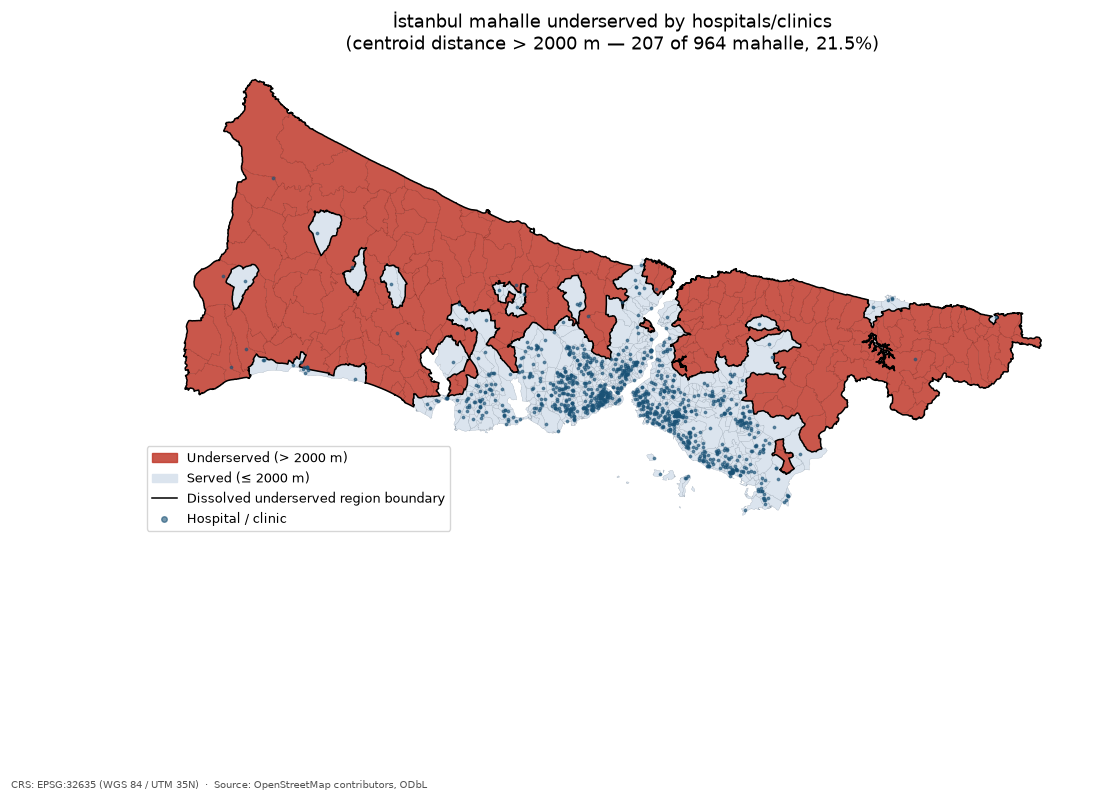

wrote ../results/figures/fig1_underserved_map.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 9))

served = merged[~merged[f"underserved_{HEADLINE_THRESHOLD_M}"]]
underserved = merged[merged[f"underserved_{HEADLINE_THRESHOLD_M}"]]

served.plot(ax=ax, color="#dbe4ee", edgecolor="#9aa7b4", linewidth=0.2)
underserved.plot(ax=ax, color="#c0392b", edgecolor="#7b1e14", linewidth=0.2, alpha=0.85)
underserved_regions.boundary.plot(ax=ax, color="black", linewidth=1.1)
hospitals.plot(ax=ax, color="#1a5276", markersize=3, alpha=0.6, zorder=5)

n_underserved = int(underserved_regions is not None) and int(merged[f"underserved_{HEADLINE_THRESHOLD_M}"].sum())
pct = 100 * n_underserved / len(merged)
ax.set_title(
    f"İstanbul mahalle underserved by hospitals/clinics\n"
    f"(centroid distance > {HEADLINE_THRESHOLD_M} m — {n_underserved} of {len(merged)} mahalle, {pct:.1f}%)",
    fontsize=13,
)
ax.set_axis_off()

legend_handles = [
    mpatches.Patch(color="#c0392b", alpha=0.85, label=f"Underserved (> {HEADLINE_THRESHOLD_M} m)"),
    mpatches.Patch(color="#dbe4ee", label=f"Served (≤ {HEADLINE_THRESHOLD_M} m)"),
    mlines.Line2D([], [], color="black", linewidth=1.1, label="Dissolved underserved region boundary"),
    mlines.Line2D([], [], color="#1a5276", marker="o", linestyle="None", markersize=4, alpha=0.6, label="Hospital / clinic"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True)
ax.annotate(
    "CRS: EPSG:32635 (WGS 84 / UTM 35N)  ·  Source: OpenStreetMap contributors, ODbL",
    xy=(0.01, 0.01), xycoords="figure fraction", fontsize=7, color="#555555",
)

fig.tight_layout()
fig1_path = FIGURES / "fig1_underserved_map.png"
fig.savefig(fig1_path, dpi=200)
plt.show()
print(f"wrote {fig1_path}")


## 4. Figure 2 — threshold sensitivity

Underserved count vs. threshold, for both of Arm 1's distance definitions
(`paper/paper.md` §4.1, `STUDY_LOG.md` "Threshold": report 1,000/1,500/2,000 m
so the headline number's sensitivity is visible; 800 m added since one
real Arm 2 run chose it). Arm 2's own runs are overlaid as scatter at
their own **(chosen threshold, chosen-threshold output-set size)** —
`paper/paper.md` §4.2–4.3 reports every successful run as an exact match
to Arm 1's boundary curve, so every scatter point is expected to land
exactly on the boundary line, not scattered around it.

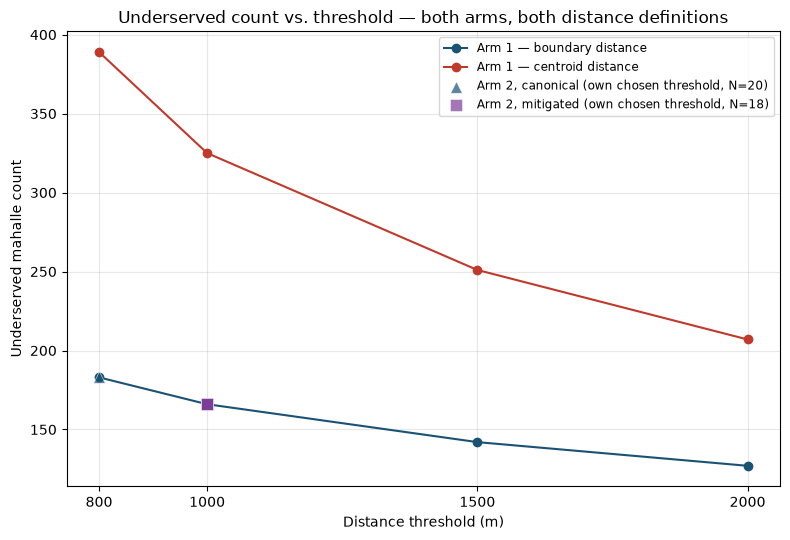

wrote ../results/figures/fig2_threshold_sensitivity.png
  800 m: boundary=183  centroid=389
  1000 m: boundary=166  centroid=325
  1500 m: boundary=142  centroid=251
  2000 m: boundary=127  centroid=207


In [5]:
boundary_counts = [int((arm1["dist_boundary_m"] > t).sum()) for t in THRESHOLDS_M]
centroid_counts = [int((arm1["dist_centroid_m"] > t).sum()) for t in THRESHOLDS_M]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(THRESHOLDS_M, boundary_counts, marker="o", color="#1a5276", label="Arm 1 — boundary distance")
ax.plot(THRESHOLDS_M, centroid_counts, marker="o", color="#c0392b", label="Arm 1 — centroid distance")

for name, batch, marker, color in (
    ("Arm 2, canonical", canonical, "^", "#1a5276"),
    ("Arm 2, mitigated", mitigated, "s", "#7d3c98"),
):
    xs = [r["threshold"] for r in batch if r["success"] and r["threshold"] is not None]
    ys = [r["n_output"] for r in batch if r["success"] and r["threshold"] is not None]
    if xs:
        ax.scatter(xs, ys, marker=marker, color=color, s=70, alpha=0.7, edgecolor="white",
                   linewidth=0.5, label=f"{name} (own chosen threshold, N={len(xs)})", zorder=5)

ax.set_xlabel("Distance threshold (m)")
ax.set_ylabel("Underserved mahalle count")
ax.set_title("Underserved count vs. threshold — both arms, both distance definitions")
ax.set_xticks(THRESHOLDS_M)
ax.grid(alpha=0.3)
ax.legend(fontsize=8.5)

fig.tight_layout()
fig2_path = FIGURES / "fig2_threshold_sensitivity.png"
fig.savefig(fig2_path, dpi=200)
plt.show()
print(f"wrote {fig2_path}")
for t, b, c in zip(THRESHOLDS_M, boundary_counts, centroid_counts):
    print(f"  {t} m: boundary={b}  centroid={c}")


## 5. Figure 3 — the boundary-vs-centroid definitional gap, at Arm 2's modal threshold

**Not an Arm 1 vs. Arm 2 disagreement** — restated from the notebook
header because it is easy to mis-title this figure. At
`ARM2_MODE_THRESHOLD_M`, three categories, computed directly from Arm 1's
own two distance columns:

- **boundary-underserved** (`dist_boundary_m > threshold`) — exactly the
  set every successful Arm 2 run outputs (`paper/paper.md` §4.2–4.3).
- **centroid-only-underserved** (`dist_centroid_m > threshold` but not
  boundary-underserved) — mahalle Arm 1's headline definition would flag
  that Arm 2's polygon-boundary definition does not; the gap named in
  `paper/paper.md` §4.4.
- **served under both** definitions.

at 1000 m:
served under both                       639
boundary-underserved (= Arm 2's set)    166
centroid-only underserved               159
Name: count, dtype: int64


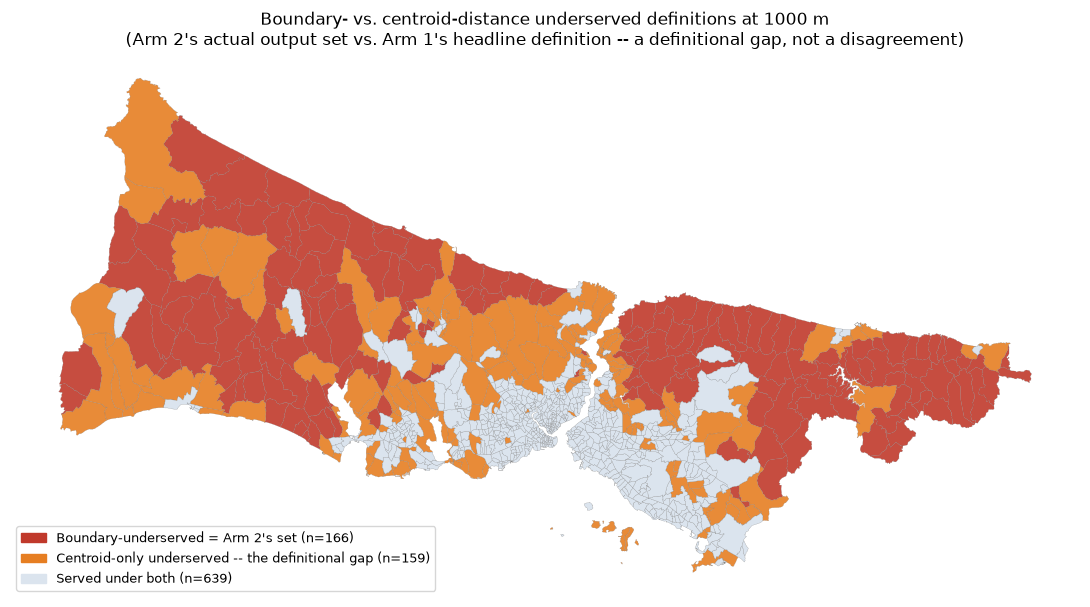

wrote ../results/figures/fig3_arm_disagreement.png


In [6]:
t = ARM2_MODE_THRESHOLD_M
boundary_flag = merged["dist_boundary_m"] > t
centroid_flag = merged["dist_centroid_m"] > t

CAT_BOUNDARY = "boundary-underserved (= Arm 2's set)"
CAT_CENTROID_ONLY = "centroid-only underserved"
CAT_SERVED = "served under both"

category = pd.Series(CAT_SERVED, index=merged.index)
category[centroid_flag & ~boundary_flag] = CAT_CENTROID_ONLY
category[boundary_flag] = CAT_BOUNDARY
merged["_gap_category"] = category

counts = category.value_counts()
n_boundary = int(counts.get(CAT_BOUNDARY, 0))
n_centroid_only = int(counts.get(CAT_CENTROID_ONLY, 0))
n_served = int(counts.get(CAT_SERVED, 0))
print(f"at {t} m:")
print(counts)
assert counts.sum() == len(merged)

color_map = {
    CAT_BOUNDARY: "#c0392b",
    CAT_CENTROID_ONLY: "#e67e22",
    CAT_SERVED: "#dbe4ee",
}

fig, ax = plt.subplots(figsize=(11, 9))
for cat, color in color_map.items():
    sub = merged[merged["_gap_category"] == cat]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="#7b7b7b", linewidth=0.15,
                  alpha=0.9 if cat != CAT_SERVED else 1.0)

ax.set_title(
    f"Boundary- vs. centroid-distance underserved definitions at {t} m\n"
    f"(Arm 2's actual output set vs. Arm 1's headline definition -- a definitional gap, not a disagreement)",
    fontsize=12,
)
ax.set_axis_off()
legend_handles = [
    mpatches.Patch(color=color_map[CAT_BOUNDARY], label=f"Boundary-underserved = Arm 2's set (n={n_boundary})"),
    mpatches.Patch(color=color_map[CAT_CENTROID_ONLY], label=f"Centroid-only underserved -- the definitional gap (n={n_centroid_only})"),
    mpatches.Patch(color=color_map[CAT_SERVED], label=f"Served under both (n={n_served})"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True)

fig.tight_layout()
fig3_path = FIGURES / "fig3_arm_disagreement.png"
fig.savefig(fig3_path, dpi=200)
plt.show()
print(f"wrote {fig3_path}")


## 6. Summary table

Reproduces `results/metrics.csv` (written by `04_comparison_metric.ipynb`)
alongside the figure paths this notebook just wrote — one place to confirm
Phase 5's numbers and Phase 6's figures agree before copying either into
`paper/paper.md`.

In [7]:
metrics_df = pd.read_csv(RESULTS / "metrics.csv")
print(metrics_df.to_string(index=False))

figure_files = sorted(p.name for p in FIGURES.glob("*.png"))
print()
print("figures written:", figure_files)


                   Arm  N  PAR                           Threshold (mean±sd) Set Stability (Jaccard)  Jaccard vs. rule-based                   |U| (mean±sd) Rank Stability (ρ, partial)  Success  Degenerate  Median latency (s)
    rule-based (Arm 1)  1  1.0 2000 ± 0 (by design; 1000/1500 also reported)   1.0 (by construction)                     1.0 207 (centroid, 2000 m headline)       1.0 (by construction)      1.0         0.0 n/a (deterministic)
LLM, canonical (Arm 2) 20  1.0                                      990 ± 44         0.9907 ± 0.0279                     1.0                     166.8 ± 3.7                      1.0000      1.0         0.0                14.4
LLM, mitigated (Arm 2) 20  0.9                                      1000 ± 0         1.0000 ± 0.0000                     1.0                     166.0 ± 0.0                      1.0000      0.9         0.0                14.3

figures written: ['fig1_underserved_map.png', 'fig2_threshold_sensitivity.png', 'fig3_arm_disag

## 7. Summary — copy this cell's real output into `paper/PLAN.md`

In [8]:
summary = {
    "mahalle_total": len(merged),
    "headline_threshold_m": HEADLINE_THRESHOLD_M,
    "underserved_headline_centroid": int(merged[f"underserved_{HEADLINE_THRESHOLD_M}"].sum()),
    "dissolved_region_pieces": len(underserved_regions),
    "arm2_mode_threshold_m": ARM2_MODE_THRESHOLD_M,
    "gap_category_counts_at_mode_threshold": category.value_counts().to_dict(),
    "threshold_sensitivity": {
        str(t): {"boundary": b, "centroid": c}
        for t, b, c in zip(THRESHOLDS_M, boundary_counts, centroid_counts)
    },
    "figures_written": figure_files,
}
print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "mahalle_total": 964,
  "headline_threshold_m": 2000,
  "underserved_headline_centroid": 207,
  "dissolved_region_pieces": 6,
  "arm2_mode_threshold_m": 1000,
  "gap_category_counts_at_mode_threshold": {
    "served under both": 639,
    "boundary-underserved (= Arm 2's set)": 166,
    "centroid-only underserved": 159
  },
  "threshold_sensitivity": {
    "800": {
      "boundary": 183,
      "centroid": 389
    },
    "1000": {
      "boundary": 166,
      "centroid": 325
    },
    "1500": {
      "boundary": 142,
      "centroid": 251
    },
    "2000": {
      "boundary": 127,
      "centroid": 207
    }
  },
  "figures_written": [
    "fig1_underserved_map.png",
    "fig2_threshold_sensitivity.png",
    "fig3_arm_disagreement.png"
  ]
}
